# Modelling a Digit Recogniser with Convolutional Neural Networks (CNNs)

## Import libraries

In [152]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

## Pre-processing digit recogniser dataset from Kaggle

In [153]:

training_data = np.loadtxt('./digit-recognizer/train.csv', delimiter=",", dtype=float, skiprows=1)
testing_data = np.loadtxt('./digit-recognizer/test.csv', delimiter=",", dtype=float, skiprows=1)

training_images = training_data[:, 1:]
training_labels = training_data[:, 0]

# Normalise down to 0-1
training_images = training_images / 255
testing_data = testing_data / 255


## Visualising labelled training dataset and unlabelled testing dataset

training Dataset


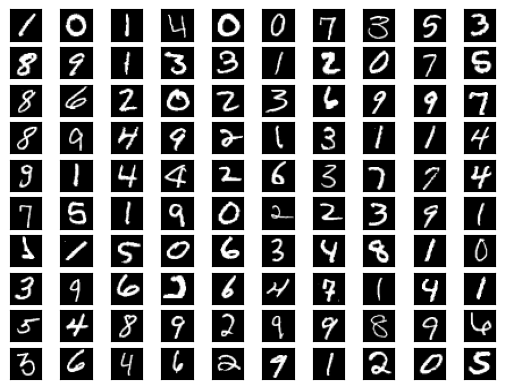

Testing Dataset


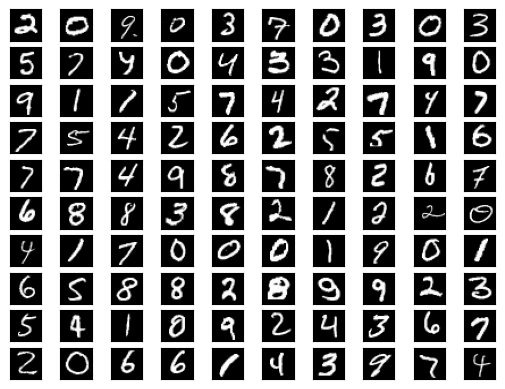

In [ ]:

# Training dataset
print("Training Dataset")
for i in range(100):
  plt.subplot(10,10,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(training_images[i].reshape(28, 28), cmap='gray')
plt.show()

# Testing dataset
print("Testing Dataset")
for i in range(100):
  plt.subplot(10,10,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(testing_data[i].reshape(28, 28), cmap='gray')
plt.show()



## Split dataset for training and testing

In [155]:
training_images = training_images.reshape(-1, 28, 28, 1)

x_train, x_test, y_train, y_test = train_test_split(training_images, training_labels, test_size=0.2)

## Applying convolutional layers and poolings

In [ ]:
model = models.Sequential()

# Block 1
model.add(layers.InputLayer(input_shape=(28, 28, 1)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Dropout(0.25))

# Block 2
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))
model.add(layers.Dropout(0.25))

# Block 3
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10))
model.summary()

Model: "sequential_25"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_98 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 conv2d_99 (Conv2D)          (None, 24, 24, 32)        9248      
                                                                 
 max_pooling2d_50 (MaxPooli  (None, 12, 12, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_64 (Dropout)        (None, 12, 12, 32)        0         
                                                                 
 conv2d_100 (Conv2D)         (None, 10, 10, 32)        9248      
                                                                 
 conv2d_101 (Conv2D)         (None, 8, 8, 64)          18496     
                                                     

## Model Training

In [157]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1050/1050 [==============================] - 8s 7ms/step - loss: 0.2995 - accuracy: 0.9040 - val_loss: 0.0676 - val_accuracy: 0.9788
Epoch 2/10
1050/1050 [==============================] - 8s 7ms/step - loss: 0.1031 - accuracy: 0.9696 - val_loss: 0.0473 - val_accuracy: 0.9836
Epoch 3/10
1050/1050 [==============================] - 8s 8ms/step - loss: 0.0760 - accuracy: 0.9780 - val_loss: 0.0417 - val_accuracy: 0.9868
Epoch 4/10
1050/1050 [==============================] - 8s 7ms/step - loss: 0.0647 - accuracy: 0.9809 - val_loss: 0.0390 - val_accuracy: 0.9882
Epoch 5/10
1050/1050 [==============================] - 8s 7ms/step - loss: 0.0568 - accuracy: 0.9828 - val_loss: 0.0366 - val_accuracy: 0.9890
Epoch 6/10
1050/1050 [==============================] - 8s 8ms/step - loss: 0.0522 - accuracy: 0.9842 - val_loss: 0.0379 - val_accuracy: 0.9876
Epoch 7/10
1050/1050 [==============================] - 8s 8ms/step - loss: 0.0437 - accuracy: 0.9871 - val_loss: 0.0368 - val_accuracy:

## Model Evaluation

263/263 [==============================] - 1s 2ms/step
Accuracy: 0.9911904761904762


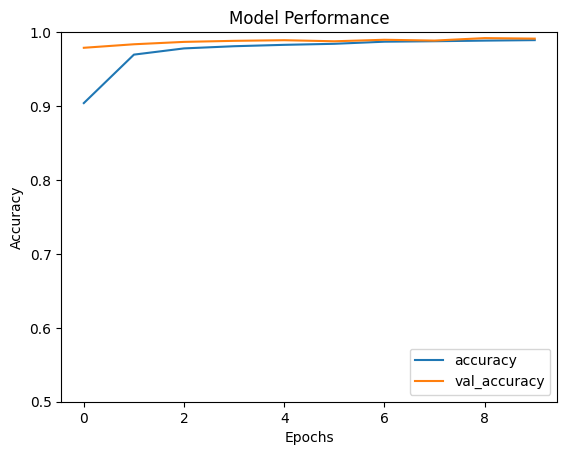

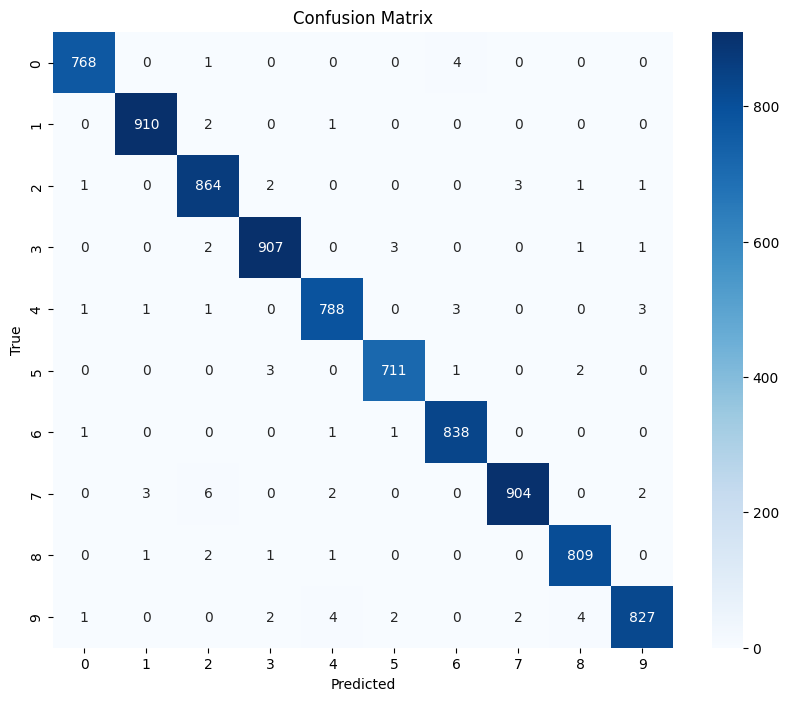

In [158]:
# Model Accuracy
pred = model.predict(x_test)
pred_labels = pred.argmax(axis=1)
acc = accuracy_score(y_test, pred_labels)
print(f"Accuracy: {acc}")

# Model Performance
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.title('Model Performance')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, pred_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Making prediction with unlabelled testing data

875/875 [==============================] - 2s 2ms/step


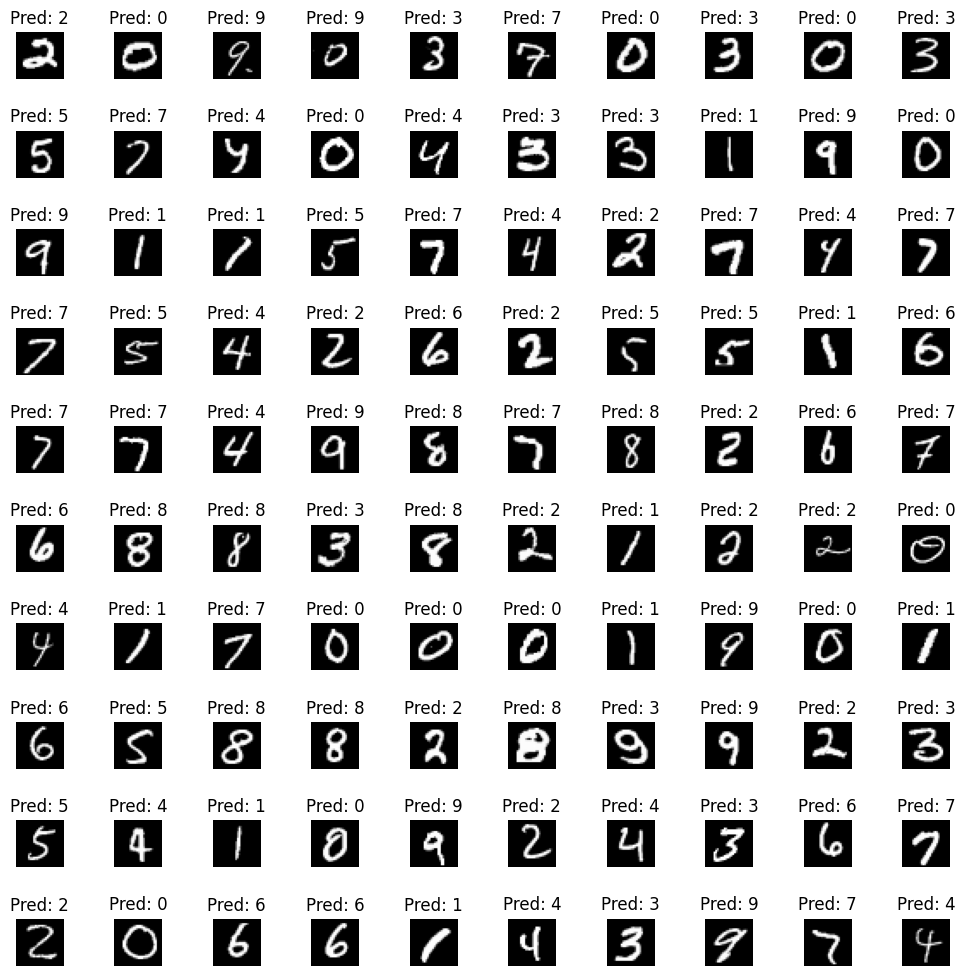

In [ ]:
testing_data = testing_data.reshape(-1, 28, 28, 1)
test_prediction = model.predict(testing_data)
test_pred_labels = test_prediction.argmax(axis=1)

submission = pd.DataFrame({
  "ImageId": range(1, len(test_pred_labels) + 1),
  "Label": test_pred_labels
})

submission.to_csv('submission.csv', index=False)

fig, axes = plt.subplots(10, 10, figsize=(10, 10))
fig.tight_layout()
for i, ax in enumerate(axes.flat):
    ax.imshow(testing_data[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {test_pred_labels[i]}")
    ax.axis('off')
plt.show()
